# Exploratory Data Analysis  

## Imports and Configuration

In [37]:
import pandas as pd
pd.set_option('display.max_columns', None)
import os
import numpy as np
import matplotlib.pyplot as plt
from dateutil.relativedelta import relativedelta

## Data Loading and Schema Review  
What does the data look like and are the dtypes correct?
- Parse `Date` as datetime

**Note:** It's a known issue with the dataset that paranthesized `Order_Demand` values represent order cancellations and need to be dealt with.
- Clean `Order_Demand`. strip parentheses, cast to numeric, note how many negative values exist before dropping them
- Filter to `Order_Demand > 0`

In [2]:
raw_data_path = os.path.expanduser("~/Desktop/data_science/projects/manufacturing_demand_forecast/data/raw/Historical Product Demand.csv")
raw_df = pd.read_csv(raw_data_path, parse_dates=['Date'])
print(raw_df.shape)
raw_df.head()

(1048575, 5)


,Product_Code,Warehouse,Product_Category,Date,Order_Demand
0,Product_0993,Whse_J,Category_028,2012-07-27,100
1,Product_0979,Whse_J,Category_028,2012-01-19,500
2,Product_0979,Whse_J,Category_028,2012-02-03,500
3,Product_0979,Whse_J,Category_028,2012-02-09,500
4,Product_0979,Whse_J,Category_028,2012-03-02,500


In [3]:
### clean Order_Demand
print("Negative row count:",len(raw_df[raw_df.Order_Demand.str.contains("\(")]))

df = raw_df[~raw_df.Order_Demand.str.contains("\(")] # drop order cancellations
df.Order_Demand = df.Order_Demand.astype(int) # cast to numeric
print(f"New data shape (no cancelled orders): {df.shape}")
df.head()

Negative row count: 10469
New data shape (no cancelled orders): (1038106, 5)


,Product_Code,Warehouse,Product_Category,Date,Order_Demand
0,Product_0993,Whse_J,Category_028,2012-07-27,100
1,Product_0979,Whse_J,Category_028,2012-01-19,500
2,Product_0979,Whse_J,Category_028,2012-02-03,500
3,Product_0979,Whse_J,Category_028,2012-02-09,500
4,Product_0979,Whse_J,Category_028,2012-03-02,500


## Data Integrity  
Where are the gaps and are they systematic?
- Missing values count per column
    - 6,669 missing `Date` values
    - Didn't find any null filler values
    - All null `Date` values are under `Whse_A` (warehouse A) only
        - Missing at Random (MAR): missingness depends on other observed features. Imputing nulls works well.
- How many unique products, warehouses, and categories?
    - `Product_Code`: 2,160
    - `Warehouse`: 4
    - `Product_Category`: 33
- Date range and coverage: are all products active across the full date range or do some start/stop mid-series?
    - Most stop mid-series
    - 4 `Product_Code` are active for less than a day, but they all have positive `Order_Demand` so I'm considering it legit

In [4]:
### missing value counts
df.isnull().sum()

Product_Code           0
Warehouse              0
Product_Category       0
Date                6669
Order_Demand           0
dtype: int64

In [5]:
## checking for null filler values
# Product_Code standard format = 'Product_NNNN'
[code for code in df.Product_Code.unique() if 'Product' not in code]

[]

In [6]:
## checking for null filler values
df.Warehouse.unique().tolist()

['Whse_J', 'Whse_S', 'Whse_C', 'Whse_A']

In [7]:
## checking for null filler values
# Product_Category standard format = 'Category_NNN'
[code for code in df.Product_Category.unique() if 'Category' not in code]

[]

In [8]:
# investigate Date nulls
# are they systematic by Warehouse?
# answer: yes
df.Warehouse[df.Date.isnull()].value_counts()

Warehouse
Whse_A    6669
Name: count, dtype: int64

In [214]:
df.Warehouse[df.Warehouse == 'Whse_A'].shape

(147179,)

In [9]:
# investigate Date nulls
# are they systematic by Product_Category?
# answer: no
df.Product_Category[df.Date.isnull()].value_counts()

Product_Category
Category_019    6463
Category_028     146
Category_005      22
Category_026      16
Category_006      13
Category_031       6
Category_021       3
Name: count, dtype: int64

In [10]:
# investigate Date nulls
# are they systematic by Product_Code?
# answer: no
df.Product_Code[df.Date.isnull()].value_counts()

Product_Code
Product_1424    710
Product_1416    657
Product_1419    569
Product_1420    516
Product_1423    464
               ... 
Product_0987      1
Product_1431      1
Product_0132      1
Product_0130      1
Product_1891      1
Name: count, Length: 82, dtype: int64

In [11]:
## unique value counts
for col in ['Product_Code','Warehouse','Product_Category']:
    print(f"{col} unique values: {df[col].nunique()}")

Product_Code unique values: 2160
Warehouse unique values: 4
Product_Category unique values: 33


In [12]:
date_coverage = (
    df
    .groupby('Product_Code')
    .agg(
        min_date=('Date','min'),
        max_date=('Date','max')
    )
    .reset_index()
    .assign(
        days_active = lambda df_: (df_.max_date - df_.min_date).dt.days
    )
)
display(date_coverage.head())
date_coverage.days_active.describe()

,Product_Code,min_date,max_date,days_active
0,Product_0001,2011-12-16,2016-12-26,1837
1,Product_0002,2011-12-23,2016-12-29,1833
2,Product_0003,2012-01-20,2016-12-22,1798
3,Product_0004,2012-01-30,2016-12-26,1792
4,Product_0005,2012-06-08,2016-11-24,1630


count    2160.000000
mean     1697.985648
std       300.300956
min         0.000000
25%      1766.000000
50%      1803.000000
75%      1816.000000
max      2182.000000
Name: days_active, dtype: float64

In [13]:
date_coverage[date_coverage.days_active == 0]

,Product_Code,min_date,max_date,days_active
464,Product_0465,2016-08-02,2016-08-02,0
848,Product_0853,2016-11-16,2016-11-16,0
1692,Product_1703,2015-10-08,2015-10-08,0
2086,Product_2099,2015-12-24,2015-12-24,0


In [14]:
no_days_active_product_codes = date_coverage.Product_Code[date_coverage.days_active == 0].tolist()
df[df.Product_Code.isin(no_days_active_product_codes)]

,Product_Code,Warehouse,Product_Category,Date,Order_Demand
765098,Product_1703,Whse_A,Category_021,2015-10-08,2
855858,Product_2099,Whse_S,Category_009,2015-12-24,163
991154,Product_0465,Whse_A,Category_012,2016-08-02,3
1008508,Product_0853,Whse_J,Category_021,2016-11-16,20


## Demand Volume Distribution  
What does the product portfolio look like in terms of volume?
- Distribution of total units demanded per product. How skewed is the portfolio?
    - Very right skewed
    - log scale adjusts distribution to near-normal distribution
- What share of products drive 80% of the volume?
    - 85 products (~0.039%)
- Breakdown by warehouse and product category

Total Products: 2160
count         2160.0
mean       2372499.0
std       15987626.0
min              2.0
25%           2690.0
50%          26072.0
75%         330844.0
max      471592000.0
Name: Order_Demand, dtype: float64


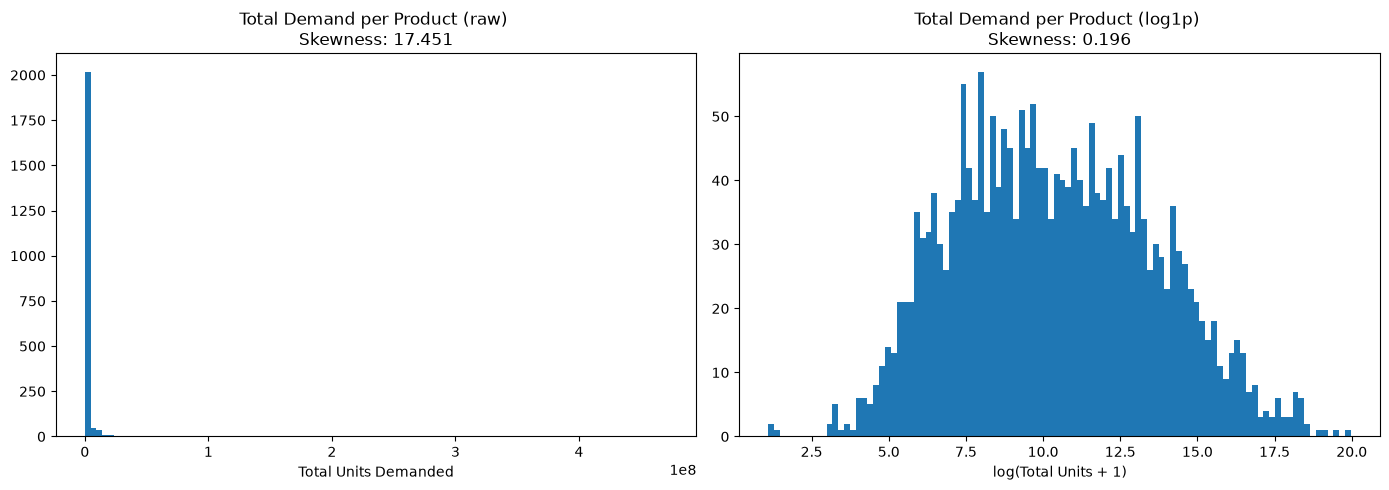

In [15]:
# distribution of demand by product
product_code_demand_totals = df.groupby('Product_Code')['Order_Demand'].sum().sort_values(ascending=False)
print(f"Total Products: {len(product_code_demand_totals)}")
print(product_code_demand_totals.describe().round())

# histogram raw and log scale. does log scale help?
fig, axes = plt.subplots(1,2,figsize=(14, 5))

axes[0].hist(product_code_demand_totals, bins=100)
axes[0].set_title(f'Total Demand per Product (raw) \nSkewness: {product_code_demand_totals.skew():.3f}')
axes[0].set_xlabel('Total Units Demanded')

axes[1].hist(np.log1p(product_code_demand_totals), bins=100)
axes[1].set_title(f'Total Demand per Product (log1p) \nSkewness: {np.log1p(product_code_demand_totals).skew():.3f}')
axes[1].set_xlabel('log(Total Units + 1)')

plt.tight_layout()
plt.show()

In [16]:
product_pareto = product_code_demand_totals.copy().sort_values().reset_index()
product_pareto['Order_Demand_Cumsum'] = product_pareto.Order_Demand.cumsum()
product_pareto['cumsum_pct_total'] = product_pareto.Order_Demand_Cumsum / product_pareto.Order_Demand.sum()
product_pareto

,Product_Code,Order_Demand,Order_Demand_Cumsum,cumsum_pct_total
0,Product_1703,2,2,3.902745e-10
1,Product_1698,2,4,7.805491e-10
2,Product_0465,3,7,1.365961e-09
3,Product_0853,20,27,5.268706e-09
4,Product_0638,22,49,9.561726e-09
...,...,...,...,...
2155,Product_1295,122647500,3983667821,7.773620e-01
2156,Product_1341,169777000,4153444821,8.104919e-01
2157,Product_0083,210539000,4363983821,8.515759e-01
2158,Product_1248,289022000,4653005821,9.079748e-01


In [17]:
# how many products drive 80% of demand?
product_pareto = product_code_demand_totals.copy().sort_values(ascending=False).reset_index()
product_pareto['pct_total'] = product_pareto.Order_Demand / product_pareto.Order_Demand.sum()
product_pareto['pct_total_cumsum'] = product_pareto.pct_total.cumsum()

sub80_count = len(product_pareto[product_pareto.pct_total_cumsum > .8])
above80_count = len(product_pareto[product_pareto.pct_total_cumsum <= .8])
print(f"{above80_count} products (~{above80_count/len(product_pareto):.3f}%) drive 80% of demand")

product_pareto[product_pareto.pct_total_cumsum <= .8].head()

85 products (~0.039%) drive 80% of demand


,Product_Code,Order_Demand,pct_total,pct_total_cumsum
0,Product_1359,471592000,0.092025,0.092025
1,Product_1248,289022000,0.056399,0.148424
2,Product_0083,210539000,0.041084,0.189508
3,Product_1341,169777000,0.033130,0.222638
4,Product_1295,122647500,0.023933,0.246571


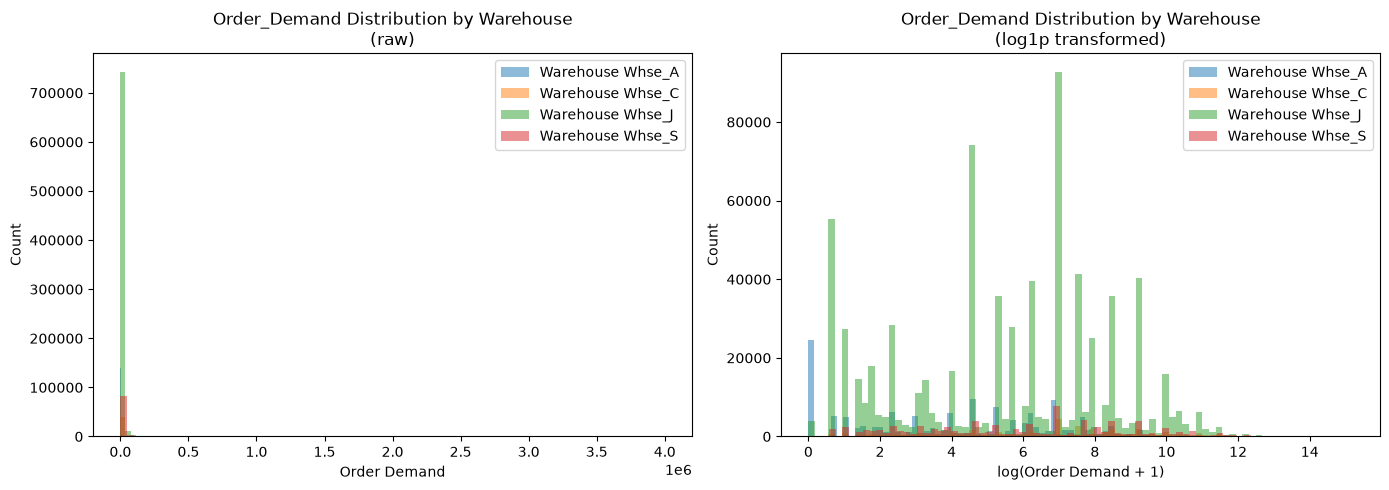

,mean,median,std,min,max
Warehouse,,,,,
Whse_A,1027.0,68.0,4340.0,0,396200
Whse_C,13814.0,1000.0,59429.0,0,3000000
Whse_J,4408.0,300.0,21185.0,0,3000000
Whse_S,11801.0,500.0,65019.0,0,4000000


In [93]:
# Order_Demand by Warehouse
fig, ax = plt.subplots(1,2, figsize=(14,5))

for warehouse in df.Warehouse.sort_values().unique():
    subset = df.Order_Demand[df.Warehouse == warehouse]
    ax[0].hist(subset, bins=80, alpha=0.5, label=f"Warehouse {warehouse}")
    log_subset = np.log1p(df.Order_Demand[df.Warehouse == warehouse])
    ax[1].hist(log_subset, bins=80, alpha=0.5, label=f"Warehouse {warehouse}")

ax[0].set_title('Order_Demand Distribution by Warehouse\n(raw)')
ax[0].set_xlabel('Order Demand')
ax[0].set_ylabel('Count')
ax[0].legend()

ax[1].set_title('Order_Demand Distribution by Warehouse\n(log1p transformed)')
ax[1].set_xlabel('log(Order Demand + 1)')
ax[1].set_ylabel('Count')
ax[1].legend()

plt.tight_layout()
plt.show()

(
    df.groupby('Warehouse')['Order_Demand']
    .agg(['mean','median','std','min','max'])
    .round()
)

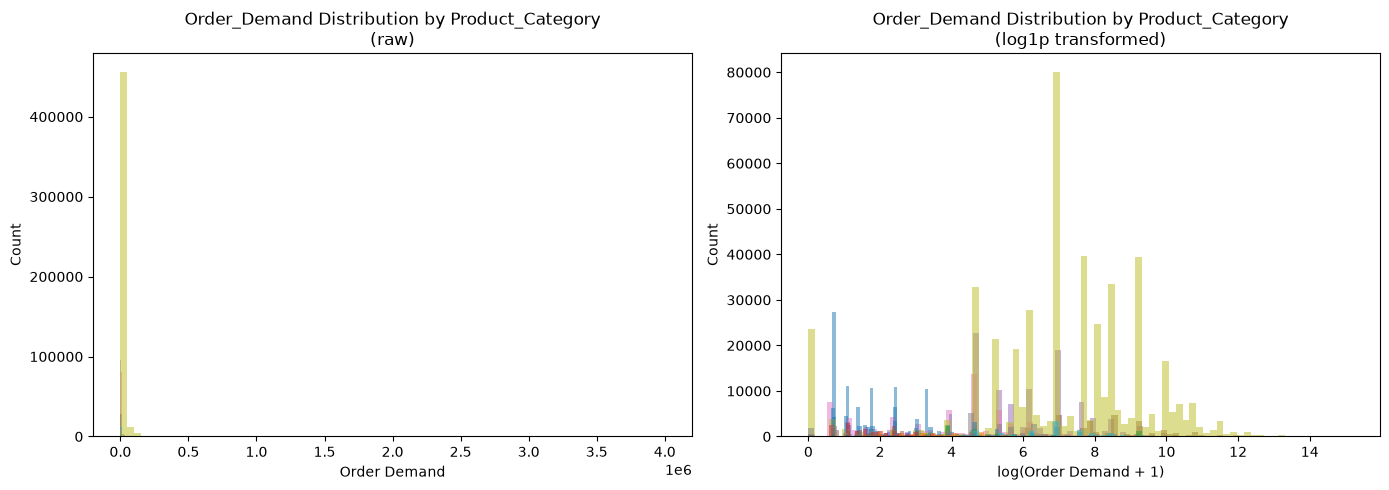

,mean,median,std,min,max
Product_Category,,,,,
Category_001,18.0,5.0,53.0,0,2075
Category_002,8.0,4.0,11.0,1,60
Category_003,94.0,30.0,195.0,0,1860
Category_004,301.0,200.0,297.0,0,2400
Category_005,1964.0,500.0,7310.0,0,500000
Category_006,11401.0,2500.0,31617.0,0,1000000
Category_007,1571.0,100.0,16231.0,0,1144000
Category_008,11.0,4.0,22.0,0,200
Category_009,191.0,50.0,491.0,0,26759


In [ ]:
# Order_Demand by Product_Category
fig, ax = plt.subplots(1,2, figsize=(14,5))

for product_cat in df.Product_Category.sort_values().unique():
    subset = df.Order_Demand[df.Product_Category == product_cat]
    ax[0].hist(subset, bins=80, alpha=0.5, label=f"Product_Category {product_cat}")
    log_subset = np.log1p(df.Order_Demand[df.Product_Category == product_cat])
    ax[1].hist(log_subset, bins=80, alpha=0.5, label=f"Product_Category {product_cat}")

ax[0].set_title('Order_Demand Distribution by Product_Category\n(raw)')
ax[0].set_xlabel('Order Demand')
ax[0].set_ylabel('Count')

ax[1].set_title('Order_Demand Distribution by Product_Category\n(log1p transformed)')
ax[1].set_xlabel('log(Order Demand + 1)')
ax[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

(
    df.groupby('Product_Category')['Order_Demand']
    .agg(['mean','median','std','min','max'])
    .round()
)

## Syntetos-Boylan Classification  
What types of demand patterns exist across the product portfolio?
1. Aggregate to monthly periods first. Daily is too sparse for ADI calc
2. Compute:
    - ADI = total months / months with non-zero demand
    - CV² = (std of non-zero demand / mean of non-zero demand)**2
3. Classify:

| Demand Type | ADI | CV² |
| --- | --- | --- |
| Smooth | < 1.32 | < 0.49 |
| Erratic | < 1.32 | >= 0.49 |
| Intermittent | >= 1.32 | < 0.49 |
| Lumpy | >= 1.32 | >= 0.49 |

In [105]:
### Demand Type by Product_Code and Warehouse ###
product_warehouse_monthly_demand = (
    df
    .groupby(['Product_Code','Warehouse',df.Date.dt.to_period('M')])
    .Order_Demand.sum()
    .reset_index()
)
# get total months
delta = relativedelta(df.Date.max(), df.Date.min())
total_months = delta.years * 12 + delta.months

# number of months with non-zero Order_Demand by Product_Code and Warehouse
product_warehouse_months_with_demand = (
    product_warehouse_monthly_demand[product_warehouse_monthly_demand.Order_Demand > 0]
    .groupby(['Product_Code','Warehouse'])
    .agg(Months_Nonzero_Demand=('Date','nunique'))
)

product_warehouse_monthly_demand = (
    product_warehouse_monthly_demand[product_warehouse_monthly_demand.Order_Demand > 0] # only keep non-zero demand
    .merge(product_warehouse_months_with_demand, how='left', on=['Product_Code','Warehouse'])
    .reset_index(drop=True)
)
# nonzero demand std/mean by Product_Code
nonzero_demand_stats = (
    product_warehouse_monthly_demand
    .groupby(['Product_Code','Warehouse']).agg(
        Nonzero_Demand_std=('Order_Demand','std'),
        Nonzero_Demand_mean=('Order_Demand','mean')
    )
    .reset_index()
)
# avoid 'unknown' demand_type because of null STD/CV2
nonzero_demand_stats['Nonzero_Demand_std'] = nonzero_demand_stats['Nonzero_Demand_std'].fillna(0)
# calculate demand categories
pw_demand_types = (
    product_warehouse_monthly_demand[['Product_Code','Warehouse','Months_Nonzero_Demand']]
    .drop_duplicates()
    .reset_index(drop=True)
    .merge(nonzero_demand_stats, how='left', on=['Product_Code','Warehouse'])
    .assign(
        ADI = lambda df_: total_months/ df_.Months_Nonzero_Demand,
        CV2 = lambda df_: (df_.Nonzero_Demand_std / df_.Nonzero_Demand_mean)**2
    )
)

# classify demand types
conditions = [
    (pw_demand_types.ADI < 1.32)&(pw_demand_types.CV2 < 0.49), # smooth
    (pw_demand_types.ADI < 1.32)&(pw_demand_types.CV2 >= 0.49), # erratic
    (pw_demand_types.ADI >= 1.32)&(pw_demand_types.CV2 < 0.49), # intermittent
    (pw_demand_types.ADI >= 1.32)&(pw_demand_types.CV2 >= 0.49) # lumpy
]
choices = ['smooth','erratic','intermittent','lumpy']
pw_demand_types['demand_type'] = np.select(conditions, choices, default='unknown')

pw_demand_types.sort_values(['Product_Code','Warehouse'])

,Product_Code,Warehouse,Months_Nonzero_Demand,Nonzero_Demand_std,Nonzero_Demand_mean,ADI,CV2,demand_type
0,Product_0001,Whse_A,60,3558.645080,5766.666667,1.200000,0.380820,smooth
1,Product_0001,Whse_J,61,973.972767,1806.557377,1.180328,0.290663,smooth
2,Product_0002,Whse_C,51,2470.809981,3343.137255,1.411765,0.546223,lumpy
3,Product_0002,Whse_S,59,143636.935054,146194.915254,1.220339,0.965312,erratic
4,Product_0003,Whse_J,60,1263.592761,1616.666667,1.200000,0.610904,erratic
...,...,...,...,...,...,...,...,...
2844,Product_2169,Whse_J,59,89.287062,80.576271,1.220339,1.227899,erratic
2845,Product_2169,Whse_S,50,178.135083,170.120000,1.440000,1.096448,lumpy
2846,Product_2170,Whse_C,57,26.174743,32.754386,1.263158,0.638596,erratic
2847,Product_2171,Whse_J,60,21.253408,36.566667,1.200000,0.337821,smooth


In [ ]:
### Product_Code x Warehouse demand types and % total of demand types ###
(
    pw_demand_types.demand_type
    .value_counts()
    .to_frame()
    .reset_index()
    .rename(columns={'count':'demand_type_count'})
    .assign(pct_total = lambda df_: (df_.demand_type_count / df_.demand_type_count.sum()).round(2))
)

,demand_type,demand_type_count,pct_total
0,lumpy,1333,0.47
1,erratic,683,0.24
2,smooth,629,0.22
3,intermittent,204,0.07


## Temporal Patterns  
Is there a trend or seasonality at the aggregate level?
- Monthly aggregate demand over time across all products
    - Avg yearly demand peaks in March, July, and October
- Breakdown by warehouse. Do warehouses show different seasonal patterns?
    - Whse_J has seasonality
    - Whse_S has some seasonality
    - Whse_C has a little bit of seasonality
    - Whse_A has almost no seasonality
- Breakdown by product category
    - Category_019 follows the aggregated avg monthly demand seasonality
    - There seems to be some seasonality for the other product categories

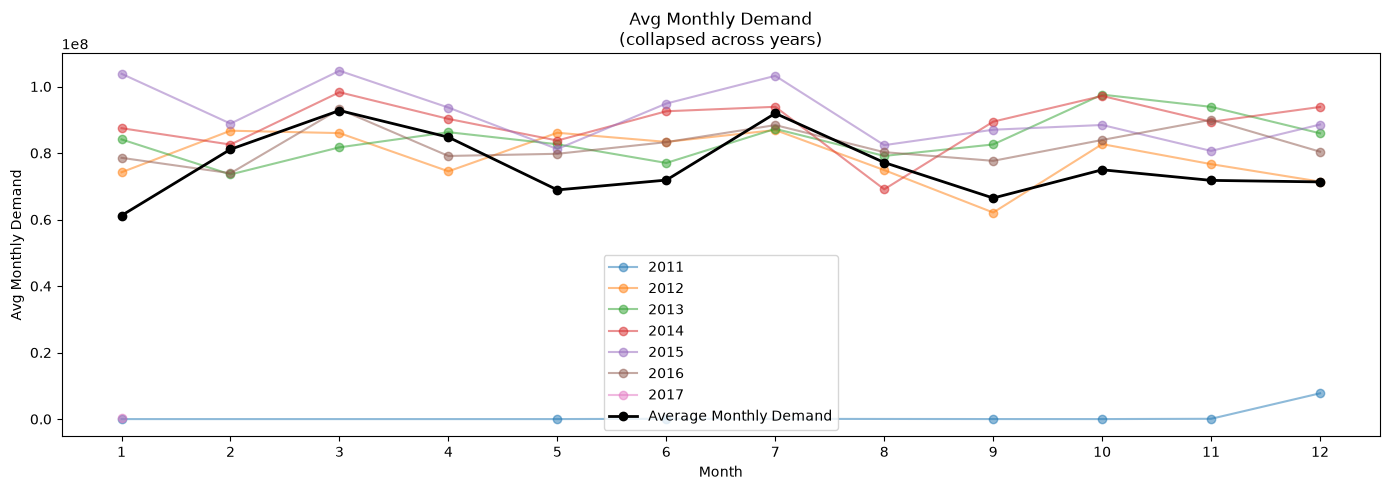

In [202]:
### Avg monthly demand ###
monthly = df.groupby(df.Date.dt.to_period('M').dt.to_timestamp()).Order_Demand.sum().reset_index()
monthly['year'] = monthly.Date.dt.year
monthly['month'] = monthly.Date.dt.month
# avg demand by month across all years
seasonality = monthly.groupby(monthly.Date.dt.month).Order_Demand.mean()

plt.figure(figsize=(14,5))

for year in sorted(monthly.year.unique()):
    subset = monthly[monthly.year == year]
    plt.plot(subset.month, subset.Order_Demand, marker='o', label=str(year), alpha=0.5)

plt.plot(seasonality.index, seasonality.values, marker='o', linewidth=2, label='Average Monthly Demand', color='black')

plt.xticks(range(1,13))
plt.xlabel('Month')
plt.ylabel('Avg Monthly Demand')
plt.title('Avg Monthly Demand\n(collapsed across years)')
plt.legend()
plt.tight_layout()
plt.show()

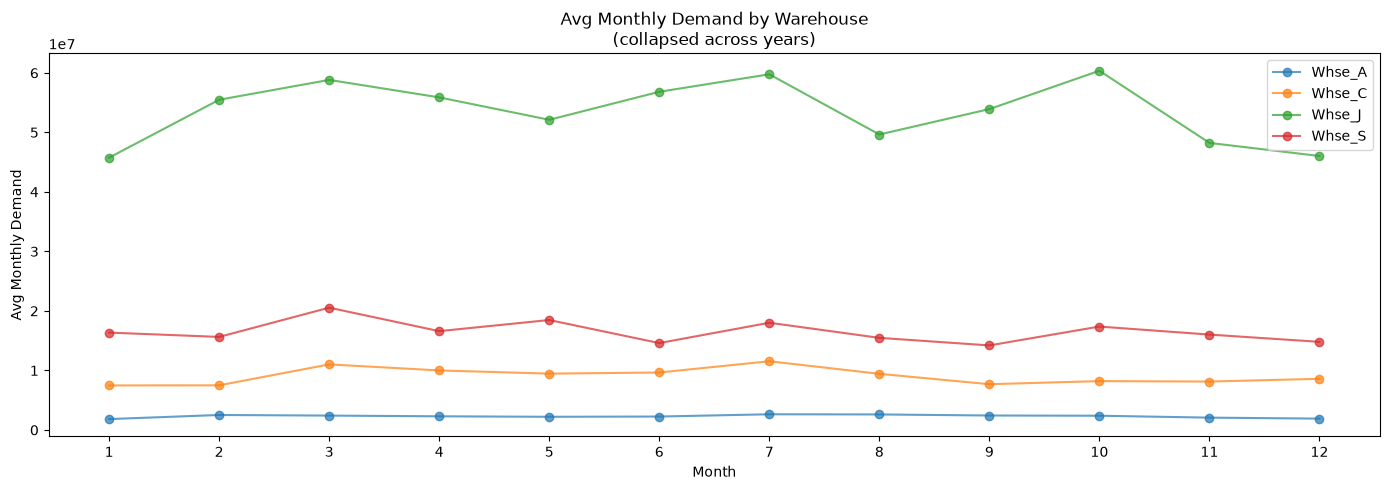

In [203]:
### Avg monthly demand by Warehouse ###
warehouse_monthly = df.groupby(['Warehouse',df.Date.dt.to_period('M').dt.to_timestamp()]).Order_Demand.sum().reset_index()
# avg warehouse demand by month across all years
seasonality_w = warehouse_monthly.groupby(['Warehouse',warehouse_monthly.Date.dt.month]).Order_Demand.mean().reset_index()

plt.figure(figsize=(14,5))

for warehouse in seasonality_w.Warehouse.unique():
    subset = seasonality_w[seasonality_w.Warehouse == warehouse]
    plt.plot(subset.Date, subset.Order_Demand, marker='o', alpha=0.7, label=warehouse)

plt.xticks(range(1,13))
plt.xlabel('Month')
plt.ylabel('Avg Monthly Demand')
plt.title('Avg Monthly Demand by Warehouse\n(collapsed across years)')
plt.legend()
plt.tight_layout()
plt.show()

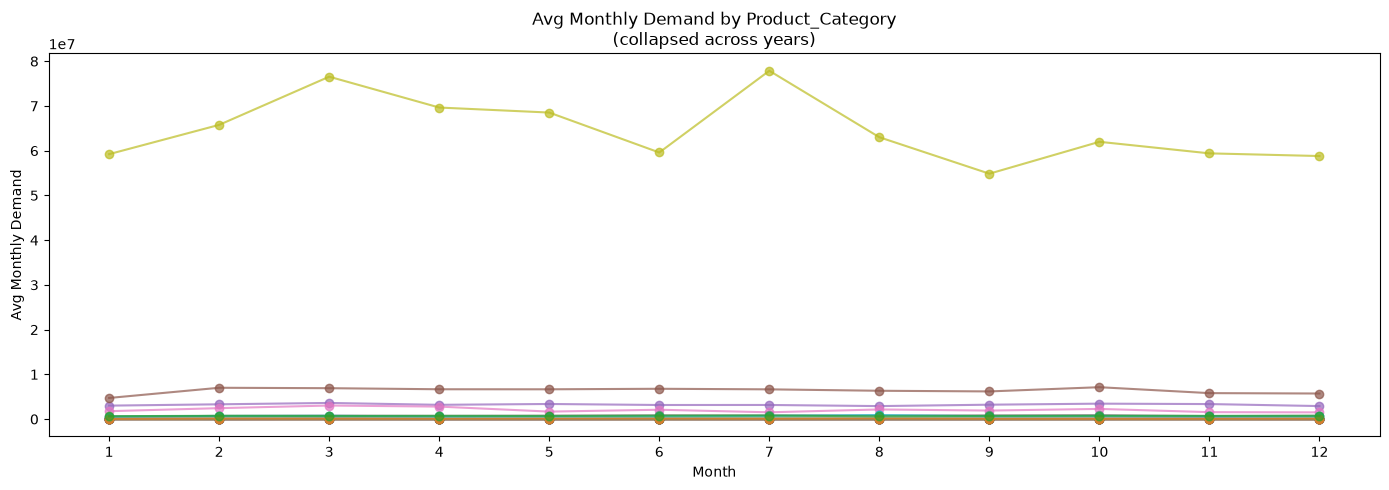

In [ ]:
### Avg monthly demand by Product_Category ###
product_cat_monthly = df.groupby(['Product_Category',df.Date.dt.to_period('M').dt.to_timestamp()]).Order_Demand.sum().reset_index()
# avg product_cat demand by month across all years
seasonality_pc = product_cat_monthly.groupby(['Product_Category',product_cat_monthly.Date.dt.month]).Order_Demand.mean().reset_index()

plt.figure(figsize=(14,5))

for product_cat in seasonality_pc.Product_Category.unique():
    subset = seasonality_pc[seasonality_pc.Product_Category == product_cat]
    plt.plot(subset.Date, subset.Order_Demand, marker='o', alpha=0.7, label=product_cat)

plt.xticks(range(1,13))
plt.xlabel('Month')
plt.ylabel('Avg Monthly Demand')
plt.title('Avg Monthly Demand by Product_Category\n(collapsed across years)')
# plt.legend() # too many product catgories for this to be feasible
plt.tight_layout()
plt.show()

In [ ]:
### The legend has too many values. Which Product_Category is that obvious line? ###
### answer: Category_019
seasonality_pc.groupby('Product_Category').Order_Demand.sum().round().sort_values(ascending=False)[:5]

Product_Category
Category_019    775223236.0
Category_006     76529506.0
Category_005     38620140.0
Category_007     24678549.0
Category_028      9234723.0
Name: Order_Demand, dtype: float64

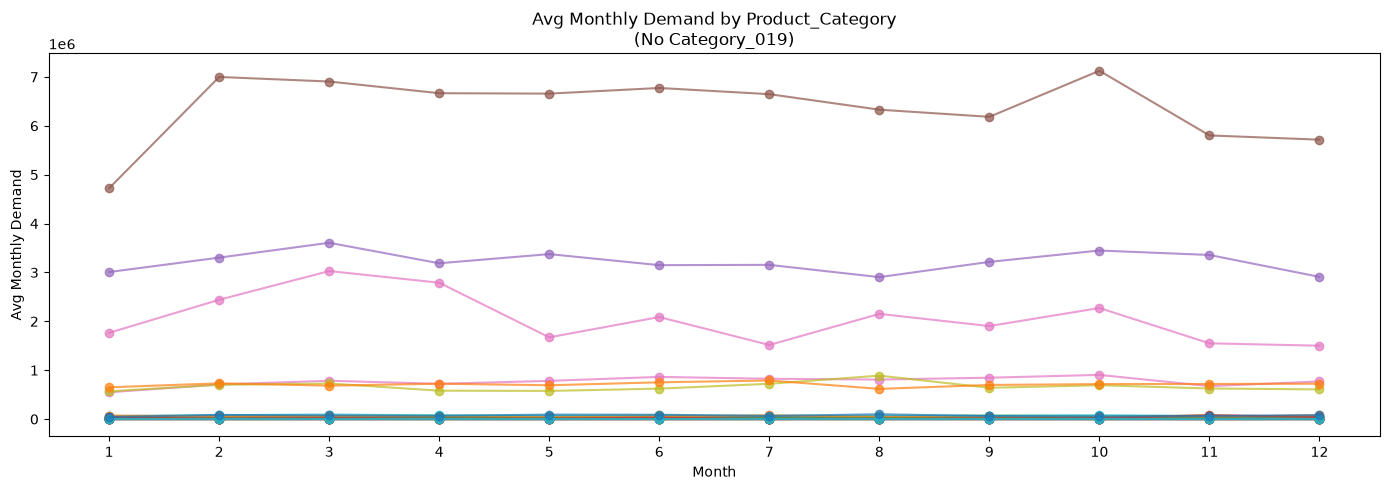

In [ ]:
### Avg monthly demand by Product_Category without Category_019 ###
product_cat_monthly = df[df.Product_Category != 'Category_019'].groupby(['Product_Category',df.Date.dt.to_period('M').dt.to_timestamp()]).Order_Demand.sum().reset_index()
# avg product_cat demand by month across all years
seasonality_pc_no19 = product_cat_monthly.groupby(['Product_Category',product_cat_monthly.Date.dt.month]).Order_Demand.mean().reset_index()

plt.figure(figsize=(14,5))

for product_cat in seasonality_pc_no19.Product_Category.unique():
    subset = seasonality_pc_no19[seasonality_pc_no19.Product_Category == product_cat]
    plt.plot(subset.Date, subset.Order_Demand, marker='o', alpha=0.7, label=product_cat)

plt.xticks(range(1,13))
plt.xlabel('Month')
plt.ylabel('Avg Monthly Demand')
plt.title('Avg Monthly Demand by Product_Category\n(No Category_019)')
plt.tight_layout()
plt.show()

## EDA Summary & Modeling Decisions

### Key Findings

| Finding | Modeling Implication |
|---|---|
| 6,669 null dates in Whse_A (4.5%) | Dropped - Missing at random, insignificant volume |
| Order_Demand right-skewed | log1p transform for modeling |
| 85 productss drive 80% of volume | All productss modeled according to demand type - inventory policy valid even for low-volume SKUs |
| 47% lumpy, 24% erratic, 22% smooth, 7% intermittent | Differentiated modeling strategy by segment (see below) |
| Seasonality peaks March, July, October | Month and WeekOfYear required as features |
| Whse_J dominates volume | Warehouse as feature - may need warehouse-level evaluation |
| Category_019 drives aggregate seasonality | Product_Category as feature |

### Modeling Strategy by Demand Segment

| Segment | % of Product_Type × Warehouse | Method | Primary Metric |
|---|---|---|---|
| Smooth | 22% | LightGBM - full feature set | MAPE |
| Erratic | 24% | LightGBM - emphasize prediction intervals | RMSE |
| Intermittent | 7% | Croston's method | MAE |
| Lumpy | 47% | Safety stock buffer dominates - LightGBM as floor estimate | Service level |

### Other Modeling Choices
- Forecast horizon = 1 month. Kaggle description of the dataset specifically mentions ocean shipping lead times exceeding one month.
- Rolling window cross validation. Gives multiple error estimates across different time windows. Helps with model generalization.